## Combined Comparison: Plain RNN vs. Encoder-Decoder vs. Additive vs. Multiplicative Attention
All four models above were trained on the identical 80/10/10 split (`random_state=20`),
identical hyperparameters, and the identical PAD/UNK-aware data pipeline in `src/data_prep.py`.
This notebook only aggregates their saved results (`outputs/results.json`).

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
from train_utils import load_results, FIG_DIR

import numpy as np
import matplotlib.pyplot as plt

results = load_results()
order = ["01_RNN", "02_Encoder_Decoder", "03_Additive_Attention", "04_Multiplicative_Attention"]
labels = ["Plain RNN", "Encoder-Decoder", "+ Additive Attention", "+ Multiplicative Attention"]
colors = ["#A480E2", '#1f77b4', '#2ca02c', '#d62728']

for k in order:
    assert k in results, f"Missing results for {k} -- run notebooks 01-04 first."

In [2]:
# summary table
print(f"{'Model':<28}{'Params':>12}{'Train Loss':>13}{'Val Loss':>11}{'BLEU-4':>9}")
print("-" * 73)
for k, lbl in zip(order, labels):
    r = results[k]
    print(f"{lbl:<28}{r['trainable_params']:>12,}{r['final_train_loss']:>13.4f}"
          f"{r['final_val_loss']:>11.4f}{r['test_bleu']:>9.4f}")

Model                             Params   Train Loss   Val Loss   BLEU-4
-------------------------------------------------------------------------
Plain RNN                      1,803,324       1.8134     4.1987   0.0100
Encoder-Decoder                1,836,348       1.7048     4.1808   0.0114
+ Additive Attention           1,885,885       0.8496     3.5583   0.1067
+ Multiplicative Attention     1,869,116       1.4897     4.0528   0.0372


In [3]:
print(f"{'Model':<28}{'PPL(val)':>10}{'Latency(ms)':>13}{'Throughput/s':>14}")
print("-" * 65)
for k, lbl in zip(order, labels):
    r = results[k]
    print(f"{lbl:<28}{r['val_perplexity']:>10.2f}{r['avg_inference_latency_ms']:>13.2f}{r['inference_throughput_sentences_per_sec']:>14.1f}")

Model                         PPL(val)  Latency(ms)  Throughput/s
-----------------------------------------------------------------
Plain RNN                        66.60         1.58         634.3
Encoder-Decoder                  65.42         1.94         516.2
+ Additive Attention             35.10         2.60         384.9
+ Multiplicative Attention       57.56         2.26         442.3


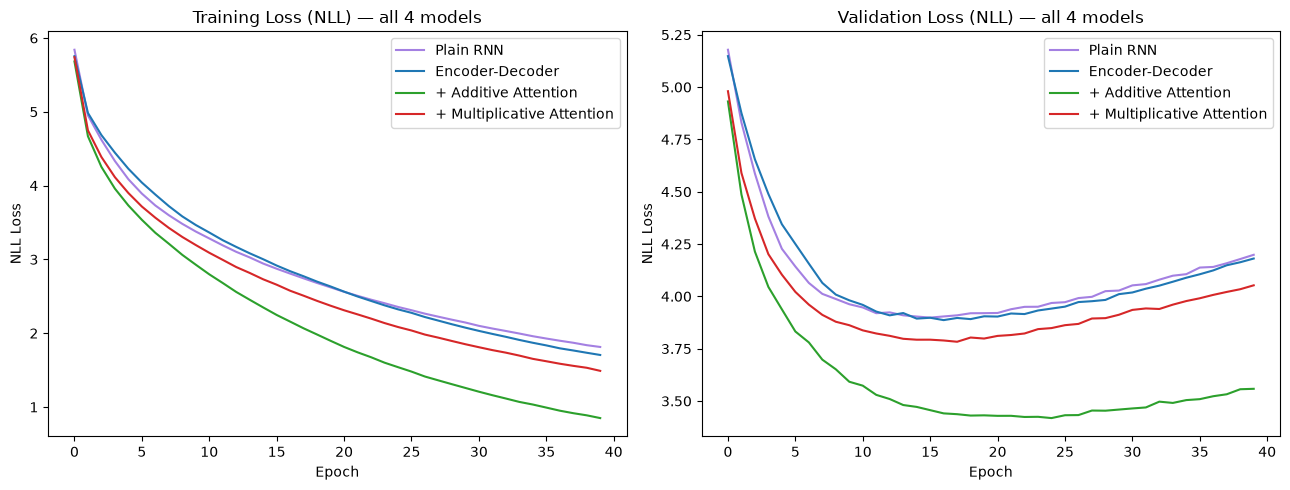

In [4]:
# combined loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for k, lbl, c in zip(order, labels, colors):
    axes[0].plot(results[k]['train_losses'], label=lbl, color=c)
    axes[1].plot(results[k]['val_losses'], label=lbl, color=c)
axes[0].set_title('Training Loss (NLL) — all 4 models'); axes[1].set_title('Validation Loss (NLL) — all 4 models')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('NLL Loss'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_combined_loss_curves.png"), dpi=120)
plt.show()

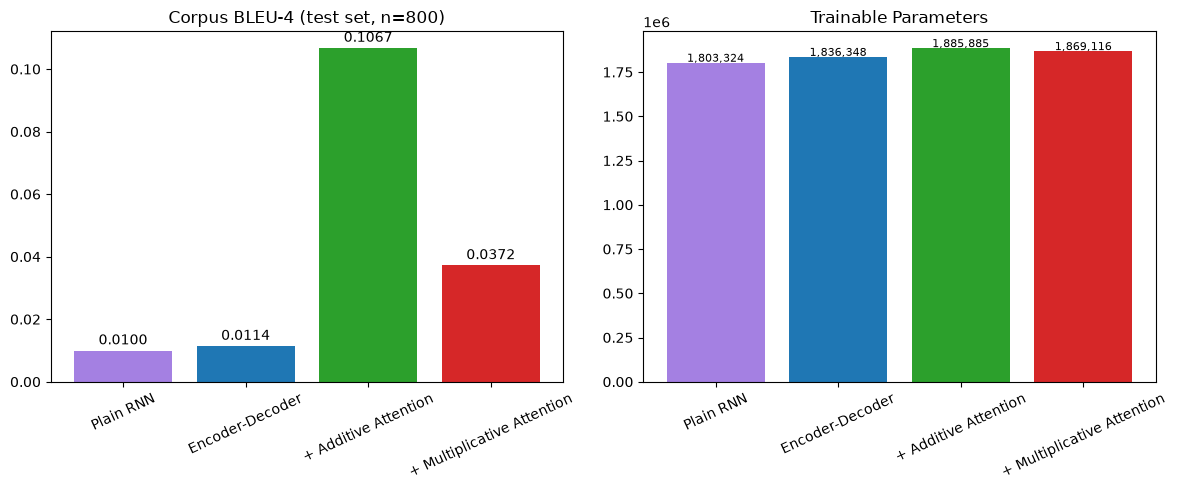

In [5]:
# BLEU + parameter count comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bleus = [results[k]['test_bleu'] for k in order]
params = [results[k]['trainable_params'] for k in order]

axes[0].bar(labels, bleus, color=colors)
axes[0].set_title('Corpus BLEU-4 (test set, n=800)'); axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(bleus): axes[0].text(i, v + 0.002, f"{v:.4f}", ha='center')

axes[1].bar(labels, params, color=colors)
axes[1].set_title('Trainable Parameters'); axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(params): axes[1].text(i, v + 5000, f"{v:,}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_bleu_params_comparison.png"), dpi=120)
plt.show()

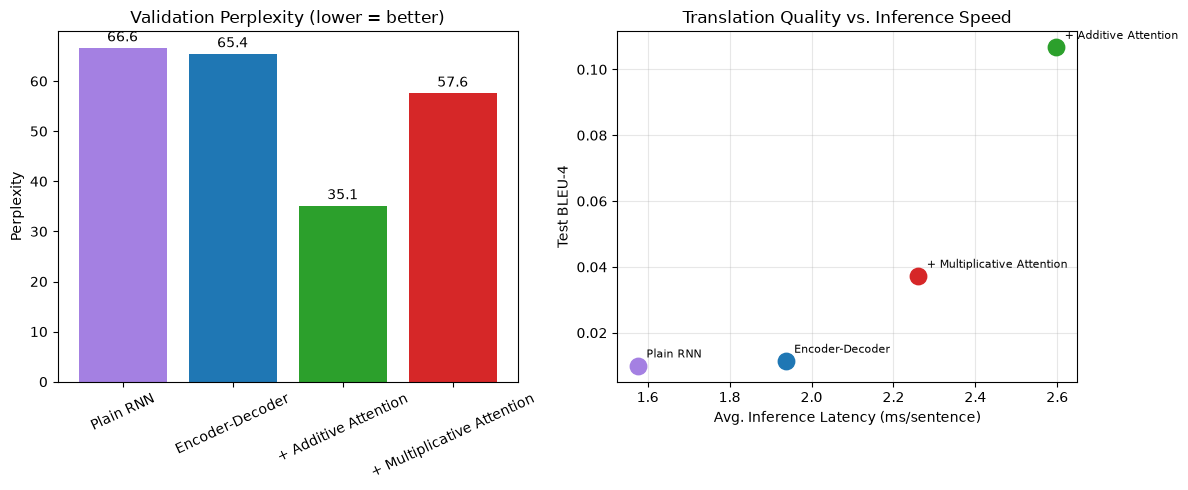

In [6]:
# Perplexity comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

val_ppls = [results[k]['val_perplexity'] for k in order]
axes[0].bar(labels, val_ppls, color=colors)
axes[0].set_title('Validation Perplexity (lower = better)')
axes[0].set_ylabel('Perplexity')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(val_ppls):
    axes[0].text(i, v + max(val_ppls) * 0.02, f"{v:.1f}", ha='center')

# BLEU vs. Latency tradeoff - shows whether slower models are "worth it"
bleus = [results[k]['test_bleu'] for k in order]
latencies = [results[k]['avg_inference_latency_ms'] for k in order]

for lbl, x, y, c in zip(labels, latencies, bleus, colors):
    axes[1].scatter(x, y, s=140, color=c, label=lbl, zorder=3)
    axes[1].annotate(lbl, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

axes[1].set_xlabel('Avg. Inference Latency (ms/sentence)')
axes[1].set_ylabel('Test BLEU-4')
axes[1].set_title('Translation Quality vs. Inference Speed')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_perplexity_latency_comparison.png"), dpi=120)
plt.show()

In [7]:
# best validation loss (not just final epoch) -- more informative once overfitting kicks in
print(f"{'Model':<28}{'Best Val Loss':>15}{'@ Epoch':>10}")
print("-" * 53)
for k, lbl in zip(order, labels):
    vl = results[k]['val_losses']
    print(f"{lbl:<28}{min(vl):>15.4f}{int(np.argmin(vl)) + 1:>10}")

Model                         Best Val Loss   @ Epoch
-----------------------------------------------------
Plain RNN                            3.8986        16
Encoder-Decoder                      3.8865        17
+ Additive Attention                 3.4185        25
+ Multiplicative Attention           3.7832        18


### **Combined Discussion**

1. Encoder-Decoder separation alone did not give a clear improvement.
The plain RNN and Encoder-Decoder models performed similarly, with BLEU-4 scores of 0.0100 and 0.0114, respectively. Both models also started to overfit after around 10–15 epochs, as their validation losses began increasing while training loss continued to decrease. This shows that simply separating the Encoder and Decoder was not enough to solve the problem, since both models still depend on a fixed context representation of the source sentence.

2. Adding attention gave the biggest improvement.
Both attention-based models performed much better than the non-attention models. Bahdanau (additive) attention achieved a BLEU-4 score of 0.1067, while Luong (multiplicative) attention achieved 0.0372. Bahdanau attention also had the lowest validation loss, reaching about 3.41, compared with about 3.78 for multiplicative attention. This shows that allowing the Decoder to focus on different parts of the source sentence was much more effective than using only a fixed context vector.

3. The type of attention also made a difference.
Bahdanau attention performed considerably better than Luong multiplicative attention, with BLEU-4 scores of 0.1067 vs. 0.0372. Therefore, it was not just the addition of attention that improved the results; the way the attention scores were calculated also affected the model's performance.

Ranking: Bahdanau Attention > Luong Multiplicative Attention > Encoder-Decoder > Plain RNN

### **Combined Conclusion**

Overall, the experiments show that attention was the most important improvement among the models tested. The plain RNN and Encoder-Decoder models produced very low BLEU scores, while adding attention resulted in a clear improvement. Among the two attention methods, Bahdanau attention performed the best, achieving a BLEU-4 score of 0.1067, compared with 0.0372 for Luong attention. This suggests that for this dataset and setup, Bahdanau attention was better at helping the Decoder focus on the relevant parts of the source sentence.

However, the results should not be treated as absolute because each model was trained with one random seed and on the 8,000-pair dataset subset, with sentences limited to 10 tokens. Therefore, the BLEU scores are relatively low, but the comparison still shows a clear trend: adding attention improves translation much more than simply separating the Encoder and Decoder, and Bahdanau attention performed best in this experiment.